In [16]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [17]:
import zipfile, os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("BSDS500")

print("Files extracted!")

Files extracted!


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob

In [19]:
image_paths = glob("BSDS500/archive/images/train/*.jpg")
print(len(image_paths))

200


In [20]:
# Load one image to test
img = cv2.imread(image_paths[5])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # display
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)    # grayscale

#THRESHOLDING
THRESHOLD = 128  # pixels above this → white, below → black (background)

_, mask = cv2.threshold(gray, THRESHOLD, 255, cv2.THRESH_BINARY)

print("Mask created!")

Mask created!


In [21]:
#GRADIENT-BASED EDGE DETECTION

#Sobel gradients
grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

#Gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

#Normalize to 0-255
gradient_magnitude = np.uint8(255 * gradient_magnitude / gradient_magnitude.max())

In [22]:
#Threshold the gradient magnitude
EDGE_THRESHOLD = 50

_, edge_image = cv2.threshold(gradient_magnitude, EDGE_THRESHOLD, 255, cv2.THRESH_BINARY)

print("Edge image created!")

Edge image created!


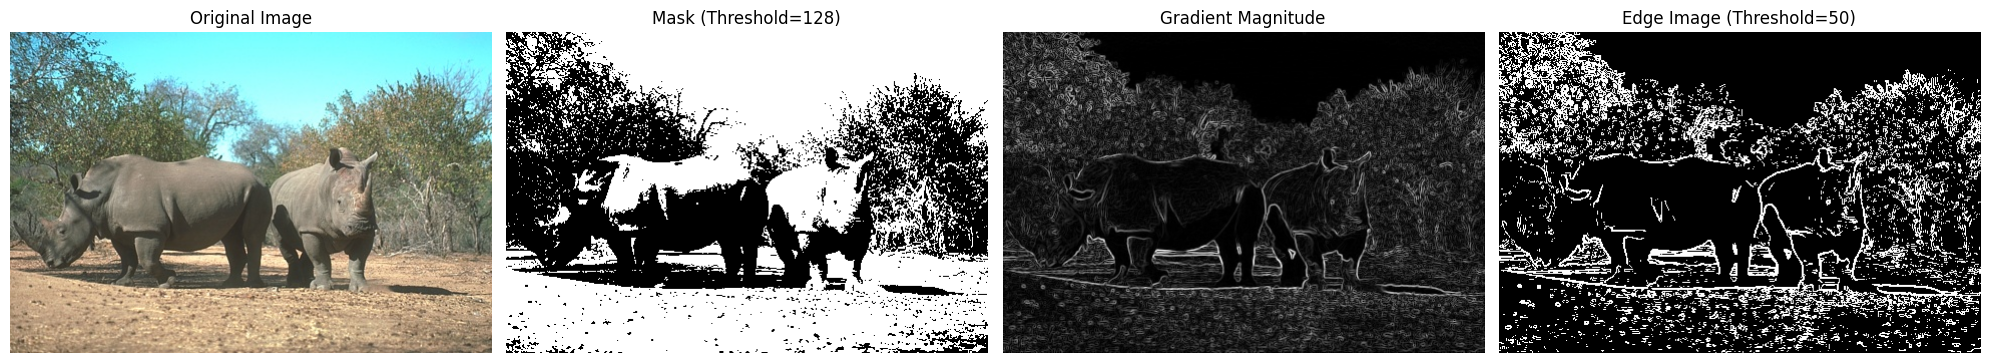

In [23]:
#Show all the results together
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Mask (Threshold={THRESHOLD})")
axes[1].axis("off")

axes[2].imshow(gradient_magnitude, cmap="gray")
axes[2].set_title("Gradient Magnitude")
axes[2].axis("off")

axes[3].imshow(edge_image, cmap="gray")
axes[3].set_title(f"Edge Image (Threshold={EDGE_THRESHOLD})")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("single_image_result.png", dpi=150)
plt.show()

In [24]:
#Create output folders
os.makedirs("output_masks", exist_ok=True)
os.makedirs("output_edges", exist_ok=True)

print("Output folders created!")

Output folders created!


In [25]:
THRESHOLD = 128      #One threshold for ALL images
EDGE_THRESHOLD = 50  #One edge threshold for ALL images

for i, path in enumerate(image_paths):

    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


    _, mask = cv2.threshold(gray, THRESHOLD, 255, cv2.THRESH_BINARY)


    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.uint8(255 * np.sqrt(grad_x**2 + grad_y**2) /
                        (np.sqrt(grad_x**2 + grad_y**2).max() + 1e-6))
    _, edge = cv2.threshold(grad_mag, EDGE_THRESHOLD, 255, cv2.THRESH_BINARY)


    filename = os.path.basename(path).replace(".jpg", ".png")
    cv2.imwrite(f"output_masks/{filename}", mask)
    cv2.imwrite(f"output_edges/{filename}", edge)

    if i % 50 == 0:
        print(f"Processed {i+1}/{len(image_paths)} images...")

print("All images processed.")

Processed 1/200 images...
Processed 51/200 images...
Processed 101/200 images...
Processed 151/200 images...
All images processed.


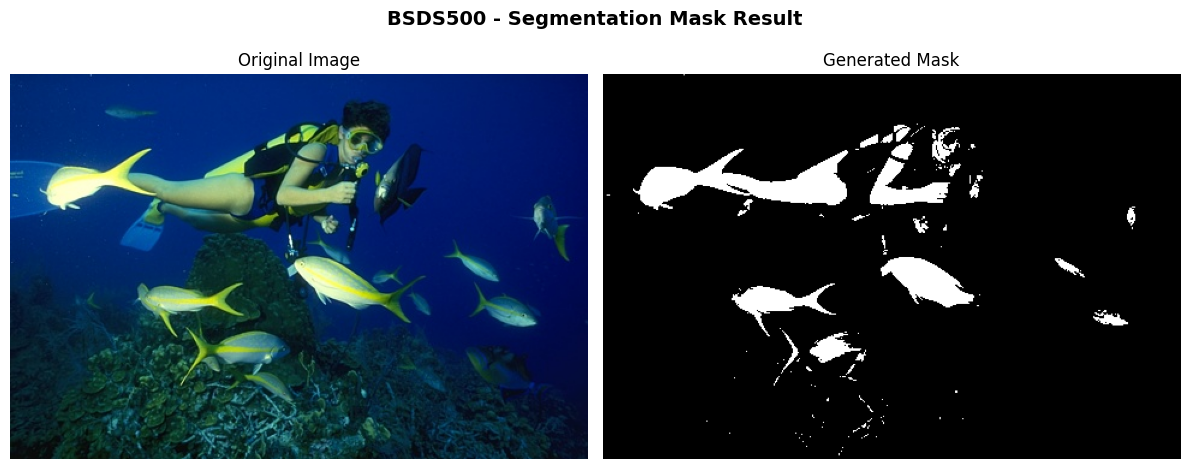

In [28]:
#Pick a random image to display
sample_path = image_paths[100]
sample_name = os.path.basename(sample_path).replace(".jpg", ".png")

original = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
saved_mask = cv2.imread(f"output_masks/{sample_name}", cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(saved_mask, cmap="gray")
axes[1].set_title("Generated Mask")
axes[1].axis("off")

plt.suptitle("BSDS500 - Segmentation Mask Result", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("final_result.png", dpi=150)
plt.show()